# Car Dekho Market Trends Analysis

## Project Overview

This project analyzes the Car Dekho vehicle dataset to understand used vehicle
pricing, depreciation, vehicle popularity and market trends.

The analysis covers manufacturing year, selling price, present price,
kilometers driven, fuel type, seller type, transmission and ownership.

### Objectives

- Analyze vehicle pricing and depreciation
- Identify popular vehicles
- Study fuel, seller and transmission patterns
- Compare cars and two-wheelers
- Identify factors affecting selling price
- Extract useful market insights through visualization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

## Loading the Dataset

In [2]:
data = pd.read_csv('/content/1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv')
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
print('Shape:', data.shape)

Shape: (301, 9)


## Initial Data Exploration

The dataset is examined using its structure, data types and statistical
summary before performing cleaning and analysis.

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [5]:
data.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [6]:
data.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [7]:
data.nunique()

,0
Car_Name,98
Year,16
Selling_Price,156
Present_Price,147
Kms_Driven,206
Fuel_Type,3
Seller_Type,2
Transmission,2
Owner,3


## Data Cleaning

The dataset is checked for duplicate records and missing values before
performing further analysis.

In [8]:
print('Duplicates:', data.duplicated().sum())
print('Missing values:', data.isnull().sum().sum())

Duplicates: 2
Missing values: 0


In [9]:
data = data.drop_duplicates().reset_index(drop=True)
print('Records after removing duplicates:', len(data))

Records after removing duplicates: 299


## Feature Engineering

Additional variables are created to analyze vehicle age, depreciation,
resale percentage and vehicle type.

In [10]:
data['Vehicle_Age'] = data['Year'].max() - data['Year']
data['Depreciation'] = data['Present_Price'] - data['Selling_Price']
data['Depreciation_%'] = data['Depreciation'] / data['Present_Price'] * 100
data['Resale_%'] = data['Selling_Price'] / data['Present_Price'] * 100

In [11]:
bike_words = ['Activa','Bajaj','Hero','Honda','Hyosung','KTM','Mahindra Mojo',
              'Royal Enfield','Suzuki Access','TVS','UM Renegade','Yamaha']

data['Vehicle_Type'] = np.where(
    data['Car_Name'].str.strip().str.startswith(tuple(bike_words)),
    'Two-Wheeler',
    'Car'
)

In [12]:
data['Vehicle_Type'].value_counts()

,count
Vehicle_Type,
Car,198
Two-Wheeler,101


## Q1. From which manufacturing year to which manufacturing year are vehicles present in this data?

In [13]:
data[['Year']].agg(['min', 'max'])

,Year
min,2003
max,2018


### Answer

The dataset contains vehicles manufactured between **2003 and 2018**.

## Q2. What is the lowest price to which a vehicle is sold?

In [14]:
data['Selling_Price'].min()

0.1

### Answer

The lowest selling price is **₹0.10 lakh (₹10,000)**.

## Q3. What is the highest price to which a vehicle is sold?

In [15]:
data['Selling_Price'].max()

35.0

### Answer

The highest selling price is **₹35 lakh**.

## Q4. How many records are there in this data?

In [17]:
original = pd.read_csv('/content/1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv')
len(original)

301

### Answer

The original dataset contains **301 records**.

After removing 2 duplicate records, the cleaned dataset contains **299 records**.

## Q5. Are there any missing records in this data?

In [18]:
data.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0
Vehicle_Age,0


### Answer

There are **no missing values** in the dataset.

## Q6. How many different vehicles are present in this data?

In [19]:
data['Car_Name'].nunique()

98

### Answer

There are **98 different vehicle models/names** in the dataset.

## Q7. Which is the most sold vehicle in this data?

In [20]:
data['Car_Name'].value_counts().head(10)

,count
Car_Name,
city,26
corolla altis,16
verna,14
brio,10
fortuner,10
ciaz,9
i20,9
innova,9
grand i10,8


### Answer

**Honda City (`city`)** is the most frequently occurring vehicle in the dataset,
with **26 records**.

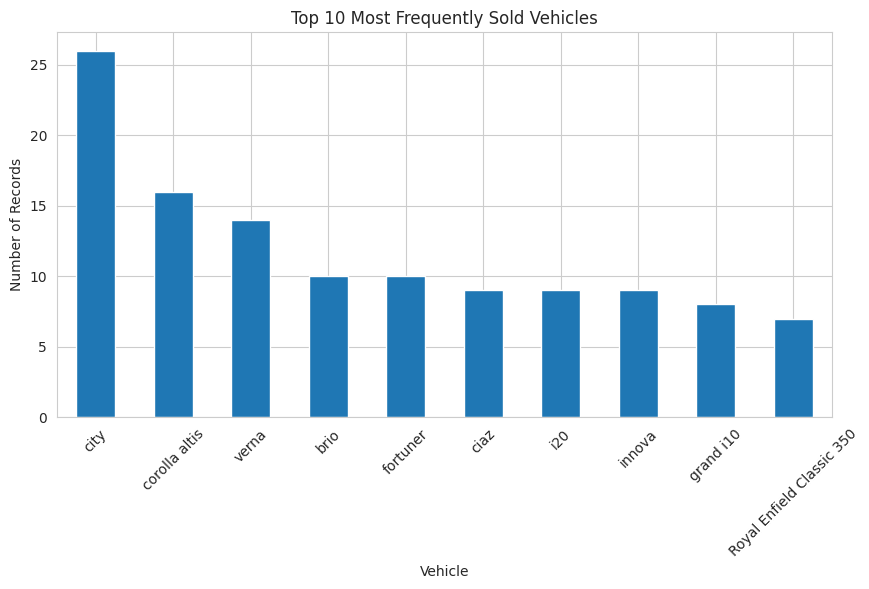

In [21]:
data['Car_Name'].value_counts().head(10).plot(kind='bar', figsize=(10,5))
plt.title('Top 10 Most Frequently Sold Vehicles')
plt.xlabel('Vehicle')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.show()

## Q8. Does the database include any CNG vehicle? If yes, how many?

In [22]:
(data['Fuel_Type'] == 'CNG').sum()

np.int64(2)

### Answer

Yes. The dataset contains **2 CNG vehicles**.

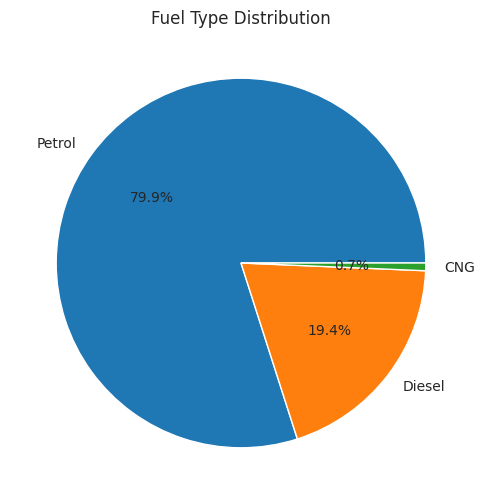

In [23]:
data['Fuel_Type'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', figsize=(6,6)
)
plt.title('Fuel Type Distribution')
plt.ylabel('')
plt.show()

## Q9. How many vehicles are for sale from individuals directly?

In [24]:
(data['Seller_Type'] == 'Individual').sum()

np.int64(106)

### Answer

There are **106 vehicles** listed by individuals directly.

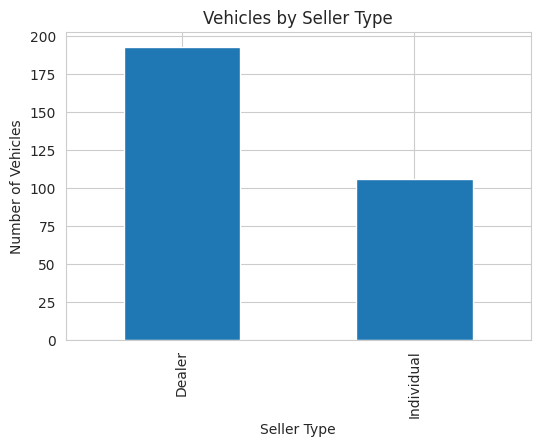

In [25]:
data['Seller_Type'].value_counts().plot(
    kind='bar', figsize=(6,4)
)
plt.title('Vehicles by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Number of Vehicles')
plt.show()

## Q10. Does this database contain automatic transmission vehicles? If yes, how many?

In [26]:
(data['Transmission'] == 'Automatic').sum()

np.int64(39)

### Answer

Yes. There are **40 automatic transmission vehicles**.

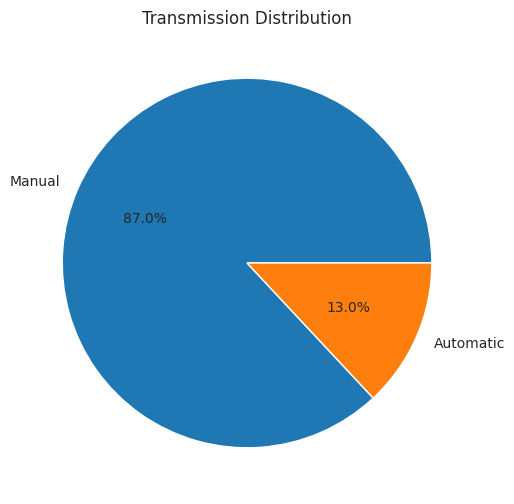

In [27]:
data['Transmission'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', figsize=(6,6)
)
plt.title('Transmission Distribution')
plt.ylabel('')
plt.show()

## Q11. How many single-person-owned vehicles are there in this database?

In [28]:
(data['Owner'] == 1).sum()

np.int64(10)

### Answer

There are **10 vehicles with one previous owner**.

## Q12. Which is the most and least cost-depreciated vehicle in the data?

In [29]:
data.loc[
    [data['Depreciation'].idxmax(), data['Depreciation'].idxmin()],
    ['Car_Name','Present_Price','Selling_Price','Depreciation']
]

,Car_Name,Present_Price,Selling_Price,Depreciation
85,land cruiser,92.60,35.00,57.60
153,Honda Activa 4G,0.51,0.48,0.03


### Answer

- **Most depreciated:** Toyota Land Cruiser — **₹57.60 lakh** depreciation.
- **Least depreciated:** Honda Activa 4G — **₹0.03 lakh** depreciation.

Depreciation is calculated as:

**Present Price − Selling Price**

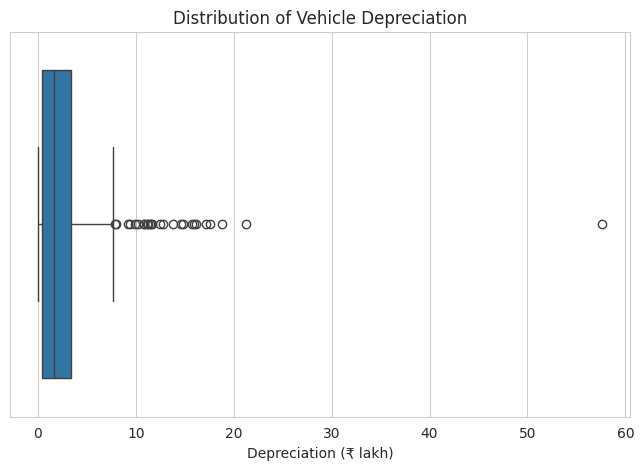

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(x=data['Depreciation'])
plt.title('Distribution of Vehicle Depreciation')
plt.xlabel('Depreciation (₹ lakh)')
plt.show()

## Q13. Which brands of vehicles are less affected by cost depreciation?

In [31]:
brand_map = {
    'ritz':'Maruti','sx4':'Maruti','wagon r':'Maruti','swift':'Maruti',
    'alto k10':'Maruti','dzire':'Maruti','ciaz':'Maruti','ertiga':'Maruti',
    's cross':'Maruti','vitara brezza':'Maruti','alto 800':'Maruti',
    'baleno':'Maruti','800':'Maruti','ignis':'Maruti','omni':'Maruti',

    'i10':'Hyundai','i20':'Hyundai','verna':'Hyundai','grand i10':'Hyundai',
    'eon':'Hyundai','xcent':'Hyundai','creta':'Hyundai','elantra':'Hyundai',

    'city':'Honda','brio':'Honda','amaze':'Honda','jazz':'Honda',

    'etios liva':'Toyota','corolla altis':'Toyota','fortuner':'Toyota',
    'innova':'Toyota','etios cross':'Toyota','etios g':'Toyota',
    'etios gd':'Toyota','camry':'Toyota','land cruiser':'Toyota','corolla':'Toyota'
}

data['Brand'] = data['Car_Name'].str.strip().str.lower().map(brand_map)

data.loc[data['Brand'].isna(), 'Brand'] = (
    data.loc[data['Brand'].isna(), 'Car_Name']
    .str.strip().str.split().str[0].str.title()
)

In [32]:
data.loc[
    data['Car_Name'].str.strip().str.lower().str.startswith('royal enfield'),
    'Brand'
] = 'Royal Enfield'

for b in ['Bajaj','Hero','Honda','Hyosung','KTM','Mahindra','Suzuki','TVS','UM','Yamaha']:
    data.loc[
        data['Car_Name'].str.strip().str.lower().str.startswith(b.lower()),
        'Brand'
    ] = b

In [33]:
brand_dep = data.groupby('Brand').agg(
    Avg_Depreciation=('Depreciation_%','mean'),
    Records=('Brand','size')
)

brand_dep[brand_dep['Records'] >= 3].sort_values('Avg_Depreciation')

,Avg_Depreciation,Records
Brand,,
Royal Enfield,26.140059,17
Hyundai,29.145760,50
Yamaha,30.649037,8
KTM,33.752237,4
TVS,33.890343,8
Activa,35.180995,3
Honda,35.335132,67
Maruti,36.381055,49
Hero,40.883727,15


### Answer

Based on average depreciation percentage, **Royal Enfield, Hyundai and Yamaha**
show relatively lower depreciation among brands with at least three records.

This conclusion is based on the average depreciation percentage within this
dataset and should not be generalized to the entire automobile market.

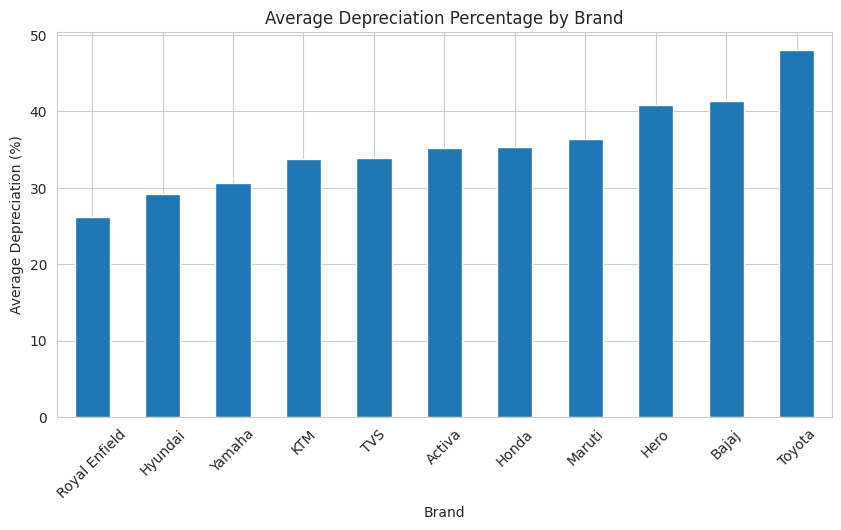

In [34]:
brand_dep[brand_dep['Records'] >= 3]['Avg_Depreciation'].sort_values().plot(
    kind='bar', figsize=(10,5)
)
plt.title('Average Depreciation Percentage by Brand')
plt.xlabel('Brand')
plt.ylabel('Average Depreciation (%)')
plt.xticks(rotation=45)
plt.show()

## Q14. Are there any factors which affect cost depreciation?

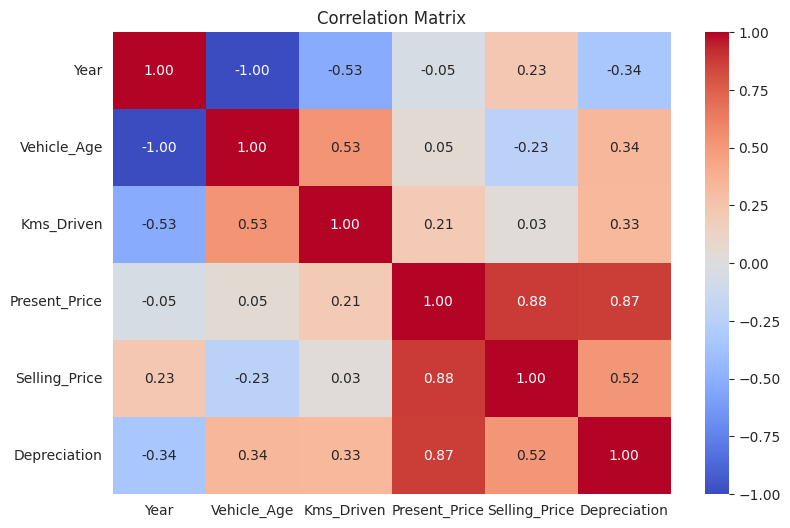

In [38]:
corr = data[
    ['Year','Vehicle_Age','Kms_Driven','Present_Price','Selling_Price','Depreciation']
].corr()

plt.figure(figsize=(9,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

### Answer

The analysis indicates that depreciation is associated with several factors,
including vehicle age, present price and kilometers driven.

Vehicle age and kilometers driven generally increase the likelihood of
depreciation, while present price has a strong relationship with absolute
depreciation.

However, correlation does not prove causation.

# Two-Wheeler Analysis

In [39]:
bikes = data[data['Vehicle_Type'] == 'Two-Wheeler'].copy()
len(bikes)

101

## Q15. In general selling price is affected by age of vehicle and distance driven by vehicle, is it observable from data?

In [40]:
bikes[['Selling_Price','Vehicle_Age','Kms_Driven']].corr()['Selling_Price']

,Selling_Price
Selling_Price,1.000000
Vehicle_Age,-0.499233
Kms_Driven,-0.280048


### Answer

Yes, the relationship is observable.

For two-wheelers, selling price has a correlation of approximately:

- **−0.50 with vehicle age**
- **−0.28 with kilometers driven**

This indicates that older and more-used two-wheelers generally tend to have
lower selling prices in this dataset.

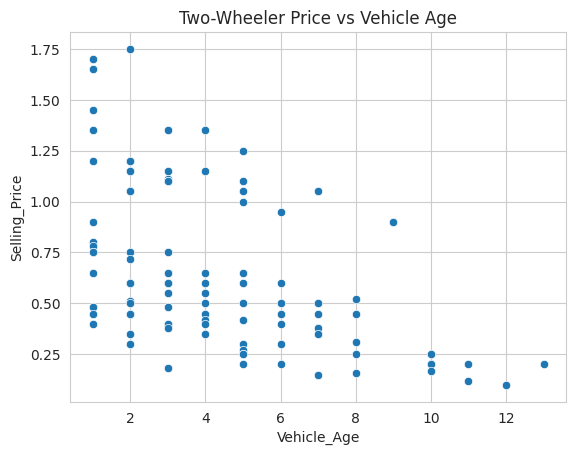

In [41]:
sns.scatterplot(data=bikes, x='Vehicle_Age', y='Selling_Price')
plt.title('Two-Wheeler Price vs Vehicle Age')
plt.show()

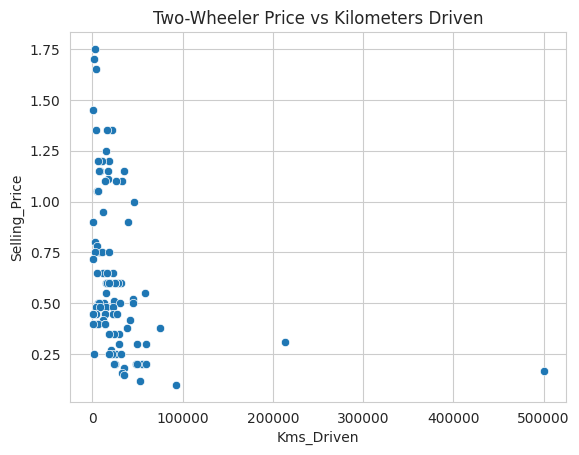

In [42]:
sns.scatterplot(data=bikes, x='Kms_Driven', y='Selling_Price')
plt.title('Two-Wheeler Price vs Kilometers Driven')
plt.show()

## Q16. Can we get an idea about newest vehicles, i.e. after 2014 manufactured?

In [43]:
bikes[bikes['Year'] > 2014][
    ['Car_Name','Year','Selling_Price']
].sort_values('Year', ascending=False)

,Car_Name,Year,Selling_Price
99,UM Renegade Mojave,2017,1.70
100,KTM RC200,2017,1.65
124,Bajaj Avenger 220,2017,0.90
101,Bajaj Dominar 400,2017,1.45
102,Royal Enfield Classic 350,2017,1.35
107,Royal Enfield Classic 350,2017,1.20
130,Bajaj Avenger 220,2017,0.75
128,Honda CB Hornet 160R,2017,0.75
171,Activa 4g,2017,0.40
156,Honda Dream Yuga,2017,0.48


### Answer

Yes. The dataset contains two-wheelers manufactured after 2014.
The newest two-wheelers in the dataset are from **2017**.

## Q17. Can we find out data of only two-wheelers from this data?

In [44]:
bikes.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Age,Depreciation,Depreciation_%,Resale_%,Vehicle_Type,Brand
98,Royal Enfield Thunder 500,2016,1.75,1.90,3000,Petrol,Individual,Manual,0,2,0.15,7.894737,92.105263,Two-Wheeler,Royal Enfield
99,UM Renegade Mojave,2017,1.70,1.82,1400,Petrol,Individual,Manual,0,1,0.12,6.593407,93.406593,Two-Wheeler,UM
100,KTM RC200,2017,1.65,1.78,4000,Petrol,Individual,Manual,0,1,0.13,7.303371,92.696629,Two-Wheeler,KTM
101,Bajaj Dominar 400,2017,1.45,1.60,1200,Petrol,Individual,Manual,0,1,0.15,9.375000,90.625000,Two-Wheeler,Bajaj
102,Royal Enfield Classic 350,2017,1.35,1.47,4100,Petrol,Individual,Manual,0,1,0.12,8.163265,91.836735,Two-Wheeler,Royal Enfield


### Answer

Yes. The dataset can be filtered using the `Vehicle_Type` column.
There are **101 two-wheeler records** in the original dataset.

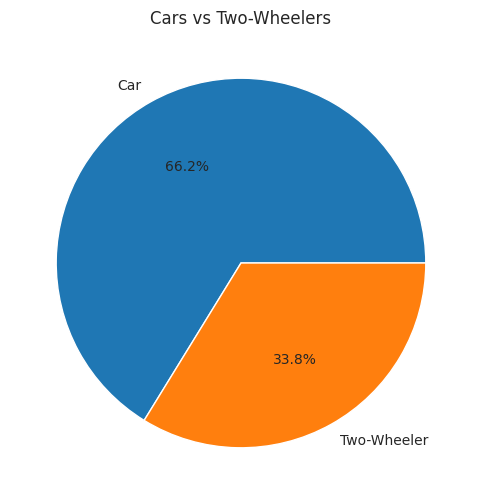

In [45]:
data['Vehicle_Type'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', figsize=(6,6)
)
plt.title('Cars vs Two-Wheelers')
plt.ylabel('')
plt.show()

## Q18. Which is the oldest bike sold here?

In [46]:
bikes.loc[bikes['Year'].idxmin(), ['Car_Name','Year','Selling_Price']]

,187
Car_Name,Hero Super Splendor
Year,2005
Selling_Price,0.2


### Answer

**Hero Super Splendor**, manufactured in **2005**, is the oldest two-wheeler
in the dataset.

## Q19. Which is the newest bike sold here?

In [47]:
bikes[bikes['Year'] == bikes['Year'].max()][
    ['Car_Name','Year','Selling_Price']
]

,Car_Name,Year,Selling_Price
99,UM Renegade Mojave,2017,1.70
100,KTM RC200,2017,1.65
101,Bajaj Dominar 400,2017,1.45
102,Royal Enfield Classic 350,2017,1.35
107,Royal Enfield Classic 350,2017,1.20
124,Bajaj Avenger 220,2017,0.90
126,Honda CB Hornet 160R,2017,0.80
127,Yamaha FZ S V 2.0,2017,0.78
128,Honda CB Hornet 160R,2017,0.75
130,Bajaj Avenger 220,2017,0.75


### Answer

The newest two-wheelers in the dataset were manufactured in **2017**.
Multiple models share this manufacturing year.

## Q20. Which is the most sold bike here?

In [49]:
bikes['Car_Name'].value_counts().head()

,count
Car_Name,
Royal Enfield Classic 350,7
Royal Enfield Thunder 350,4
Bajaj Pulsar 150,4
Bajaj Avenger 220,3
Royal Enfield Thunder 500,3


### Answer

**Royal Enfield Classic 350** is the most frequently occurring two-wheeler,
with **7 records**.

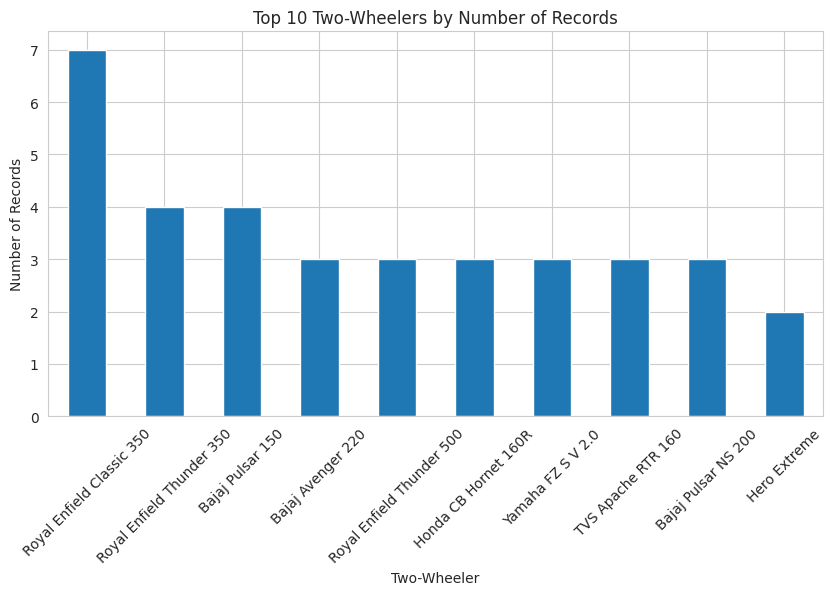

In [50]:
bikes['Car_Name'].value_counts().head(10).plot(
    kind='bar', figsize=(10,5)
)
plt.title('Top 10 Two-Wheelers by Number of Records')
plt.xlabel('Two-Wheeler')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.show()

## Q21. Do you find any deal in two-wheelers which exceeded the general expectation? Can you find the reason for it?

In [51]:
bikes.sort_values('Resale_%', ascending=False)[
    ['Car_Name','Year','Selling_Price','Present_Price','Kms_Driven','Resale_%']
].head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Resale_%
124,Bajaj Avenger 220,2017,0.90,0.95,1300,94.736842
153,Honda Activa 4G,2017,0.48,0.51,4300,94.117647
125,Bajaj Avenger 150,2016,0.75,0.80,7000,93.750000
99,UM Renegade Mojave,2017,1.70,1.82,1400,93.406593
127,Yamaha FZ S V 2.0,2017,0.78,0.84,5000,92.857143


### Answer

Yes.

The strongest example is a **Bajaj Avenger 220 (2017)** with:

- Selling Price: ₹0.90 lakh
- Present Price: ₹0.95 lakh
- Resale ratio: approximately **94.7%**
- Kilometers driven: **1,300 km**

Its relatively recent manufacturing year and very low kilometers driven are
possible reasons for its unusually high resale value.

# Car Analysis

In [52]:
cars = data[data['Vehicle_Type'] == 'Car'].copy()
len(cars)

198

## Q22. Can we find out data of only cars from this data?

In [53]:
cars.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Age,Depreciation,Depreciation_%,Resale_%,Vehicle_Type,Brand
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,4,2.24,40.071556,59.928444,Car,Maruti
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,5,4.79,50.209644,49.790356,Car,Maruti
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,1,2.60,26.395939,73.604061,Car,Maruti
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,7,1.30,31.325301,68.674699,Car,Maruti
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,4,2.27,33.042213,66.957787,Car,Maruti


### Answer

Yes. The car records can be obtained by filtering `Vehicle_Type == 'Car'`.

The original dataset contains **200 car records**.

## Q23. Which is the oldest car sold here?

In [54]:
cars[cars['Year'] == cars['Year'].min()][
    ['Car_Name','Year','Selling_Price']
]

,Car_Name,Year,Selling_Price
36,800,2003,0.35
38,sx4,2003,2.25


### Answer

The oldest cars in the dataset were manufactured in **2003**.

The records include **Maruti 800 (`800`)** and **Maruti SX4 (`sx4`)**.

## Q24. Which is the newest car sold here?

In [55]:
cars[cars['Year'] == cars['Year'].max()][
    ['Car_Name','Year','Selling_Price']
]

,Car_Name,Year,Selling_Price
5,vitara brezza,2018,9.25


### Answer

**Vitara Brezza**, manufactured in **2018**, is the newest car in the dataset.$0

## Q25. Do you find any deal in cars which exceeded the general expectation? Can you find the reason for it?

In [56]:
cars.sort_values('Resale_%', ascending=False)[
    ['Car_Name','Year','Selling_Price','Present_Price','Kms_Driven','Resale_%']
].head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Resale_%
79,corolla altis,2016,14.73,14.89,23000,98.925453
8,ciaz,2016,8.75,8.89,20273,98.425197
229,verna,2017,9.25,9.40,15001,98.404255
206,i20,2017,7.90,8.10,3435,97.530864
233,verna,2017,9.10,9.40,15141,96.808511


### Answer

Yes.

The strongest example is **Corolla Altis (2016)**:

- Selling Price: ₹14.73 lakh
- Present Price: ₹14.89 lakh
- Resale ratio: approximately **98.9%**
- Kilometers driven: 23,000 km

Its relatively recent manufacturing year and moderate kilometers driven may
help explain the unusually high resale ratio.

## Selling Price Distribution

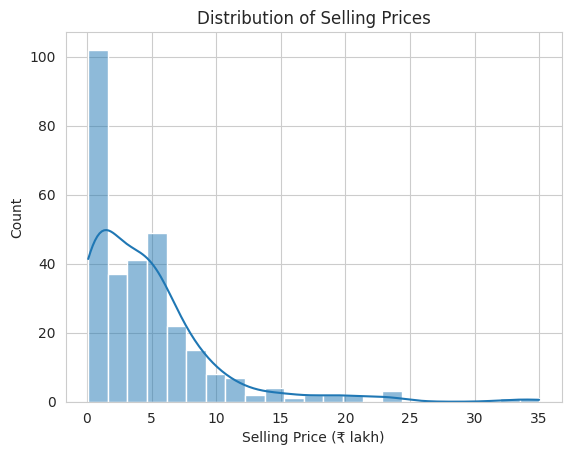

In [57]:
sns.histplot(data['Selling_Price'], kde=True)
plt.title('Distribution of Selling Prices')
plt.xlabel('Selling Price (₹ lakh)')
plt.show()

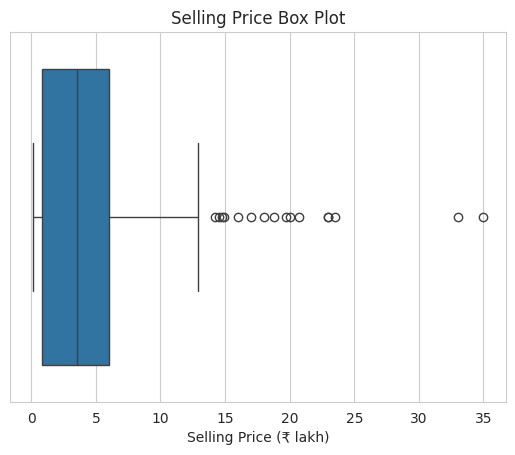

In [59]:
sns.boxplot(x=data['Selling_Price'])
plt.title('Selling Price Box Plot')
plt.xlabel('Selling Price (₹ lakh)')
plt.show()

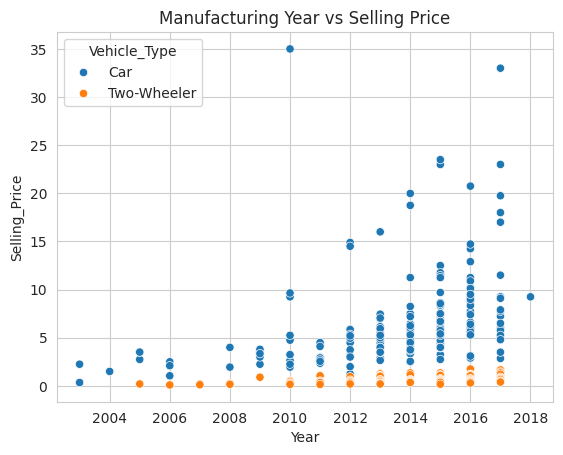

In [60]:
sns.scatterplot(data=data, x='Year', y='Selling_Price',
                hue='Vehicle_Type')
plt.title('Manufacturing Year vs Selling Price')
plt.show()

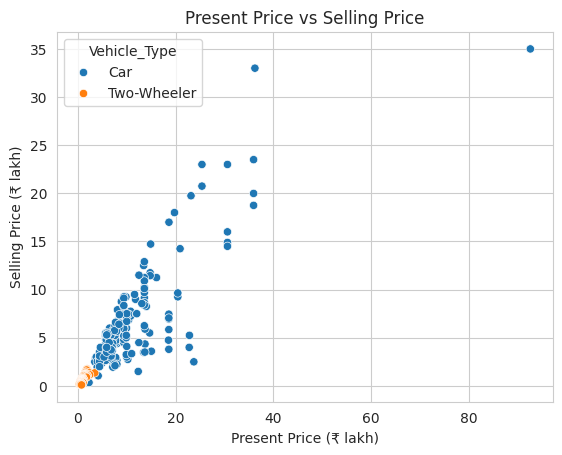

In [62]:
sns.scatterplot(data=data, x='Present_Price', y='Selling_Price',
                hue='Vehicle_Type')
plt.title('Present Price vs Selling Price')
plt.xlabel('Present Price (₹ lakh)')
plt.ylabel('Selling Price (₹ lakh)')
plt.show()

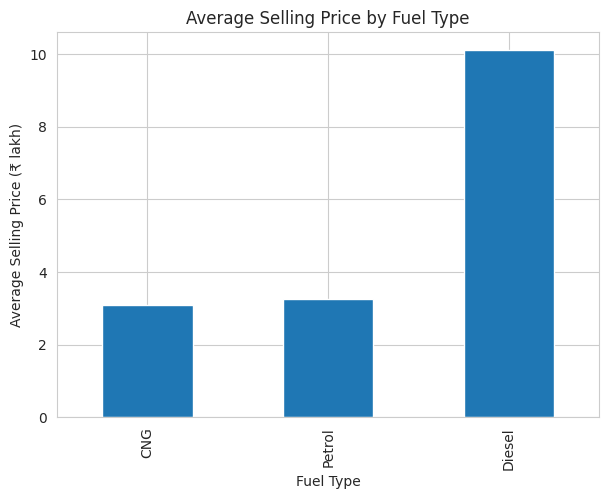

In [63]:
data.groupby('Fuel_Type')['Selling_Price'].mean().sort_values().plot(
    kind='bar', figsize=(7,5)
)
plt.title('Average Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Selling Price (₹ lakh)')
plt.show()

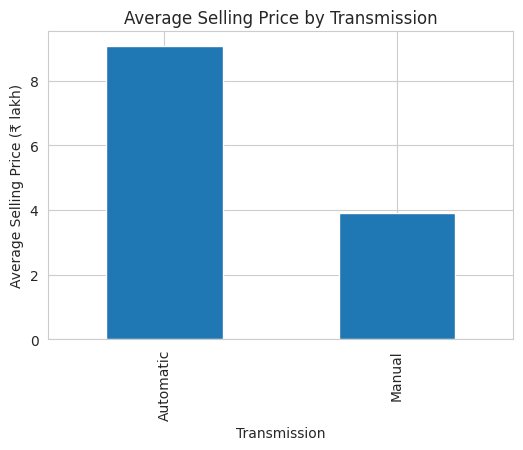

In [64]:
data.groupby('Transmission')['Selling_Price'].mean().plot(
    kind='bar', figsize=(6,4)
)
plt.title('Average Selling Price by Transmission')
plt.ylabel('Average Selling Price (₹ lakh)')
plt.show()

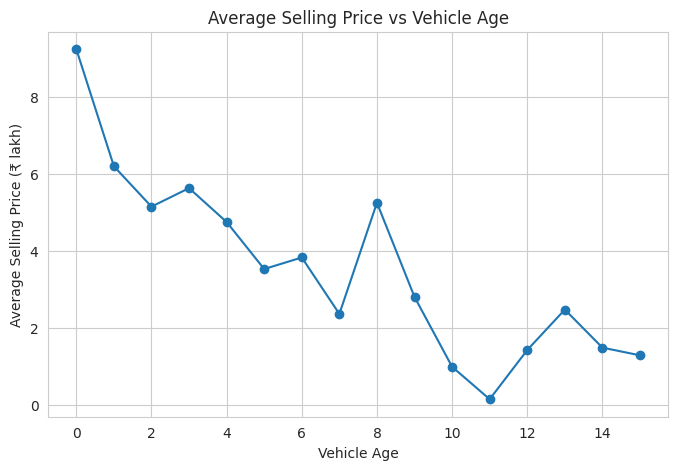

In [65]:
data.groupby('Vehicle_Age')['Selling_Price'].mean().plot(
    kind='line', marker='o', figsize=(8,5)
)
plt.title('Average Selling Price vs Vehicle Age')
plt.xlabel('Vehicle Age')
plt.ylabel('Average Selling Price (₹ lakh)')
plt.show()

# Key Findings

In [66]:
summary = {
    'Original Records': len(original),
    'Unique Vehicles': original['Car_Name'].nunique(),
    'Year Range': f"{original['Year'].min()}–{original['Year'].max()}",
    'Minimum Selling Price': original['Selling_Price'].min(),
    'Maximum Selling Price': original['Selling_Price'].max(),
    'CNG Vehicles': (original['Fuel_Type'] == 'CNG').sum(),
    'Automatic Vehicles': (original['Transmission'] == 'Automatic').sum(),
    'Individual Sellers': (original['Seller_Type'] == 'Individual').sum()
}

pd.Series(summary)

,0
Original Records,301
Unique Vehicles,98
Year Range,2003–2018
Minimum Selling Price,0.1
Maximum Selling Price,35.0
CNG Vehicles,2
Automatic Vehicles,40
Individual Sellers,106


# Conclusion

The Car Dekho dataset contains 301 original records covering vehicles
manufactured between 2003 and 2018.

The analysis shows that petrol and manual-transmission vehicles dominate the
dataset. Honda City is the most frequently occurring vehicle overall, while
Royal Enfield Classic 350 is the most frequently occurring two-wheeler.

Selling prices range from ₹0.10 lakh to ₹35 lakh. Depreciation varies
substantially between vehicles, with vehicle age, present price and kilometers
driven being important variables to consider.

The analysis also identifies high-resale vehicles among both cars and
two-wheelers. Overall, exploratory data analysis and visualization provide
useful insights into used-vehicle pricing and depreciation patterns.